In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn. model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.ticker import FuncFormatter


In [14]:
data = pd.read_csv('C:\Study content\ML\DATASETS\Book1.csv')
X = data.drop('Price', axis=1)
y = data['Price']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2,random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R^2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Mean Squared Error: 147548850950960.72
R^2 Score: -0.04
Model Coefficients: [ 1.27608811e+06 -4.22430955e+05 -4.26265705e+02  5.33854122e+05]
Model Intercept: 26487033.34301112


Predicted price for the house: ₹26,289,700.21


Text(0.5, 1.0, 'Actual vs Predicted House Prices')

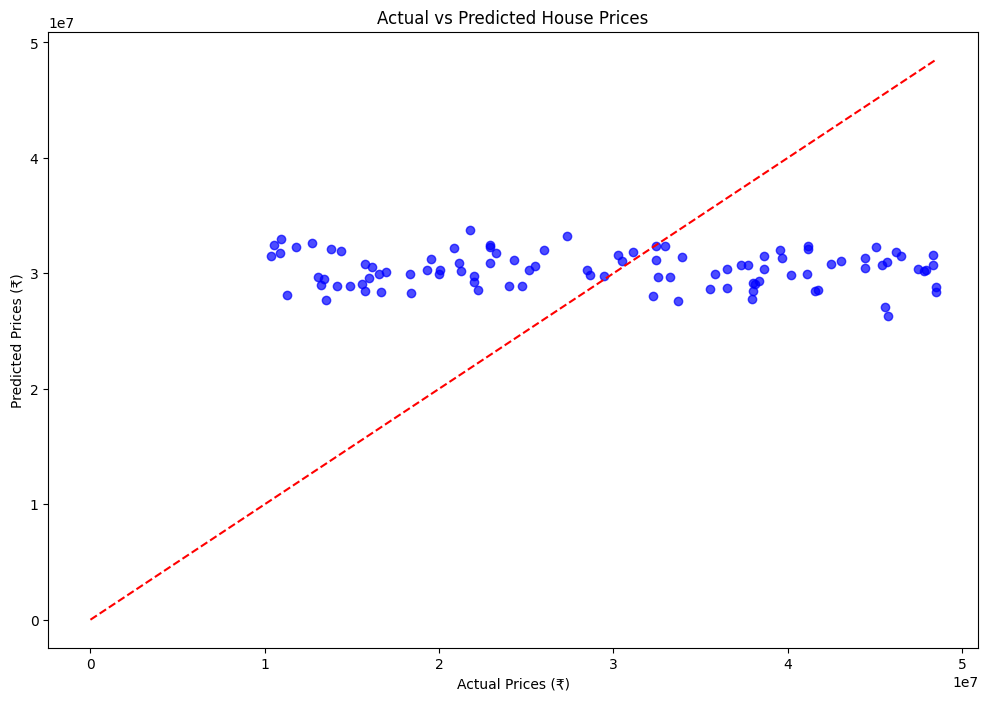

In [21]:
area = float(input("Enter area (sq ft): "))
bedrooms = int(input("Enter number of bedrooms: "))
floors = int(input("Enter number of floors: "))
age = int(input("Enter age of the house: "))
# Ensure input columns align with training feature order
input_data = pd.DataFrame([[floors, bedrooms, area, age]], columns=X.columns)
input_data_encoded = input_data.reindex(columns=X.columns, fill_value=0)
predicted_price = model.predict(input_data_encoded)
print(f"Predicted price for the house: ₹{predicted_price[0]:,.2f}")
plt.figure(figsize=(12, 8)) # Adjusted size
plt.scatter(y_test, y_pred, alpha=0.7, label="Predicted Prices", color='blue', marker='o')
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--', label="Prediction Line")
plt.xlabel("Actual Prices (₹)")
plt.ylabel("Predicted Prices (₹)")
plt.title("Actual vs Predicted House Prices")

C:\Users\Acer\AppData\Local\Temp\ipykernel_18732\1360668970.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


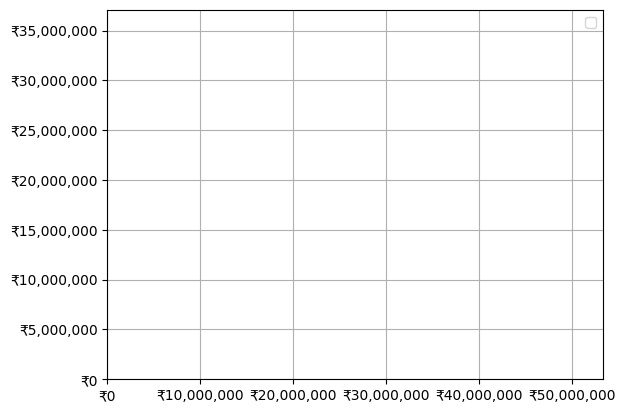

In [22]:
formatter = FuncFormatter(lambda x, pos: f'₹{int(x):,}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.legend()
plt.xlim(0, max(y_test) * 1.1)
plt.ylim(0, max(y_pred) * 1.1)
# Grid and display
plt.grid(True)